# Лабораторная работа №1 (CV)
## Вариант на 3: обнаружение и распознавание объектов (Ultralytics YOLOv11)

Цель работы заключается в исследовании возможностей моделей семейства YOLOv11 для задачи обнаружения и распознавания объектов на изображениях. В рамках работы необходимо обучить baseline-модель, проверить гипотезы по улучшению качества, а также сравнить результаты предобученной модели и модели, обученной с нуля.

В работе используется датасет **Chess Pieces (YOLO format)**. Он был выбран потому, что хорошо подходит для задачи детекции объектов: изображения содержат несколько классов объектов, для них уже подготовлена разметка ограничивающими прямоугольниками, а сама задача имеет понятный практический смысл — автоматическое распознавание шахматных фигур на изображении доски. Кроме того, датасет удобно использовать вместе с `ultralytics`, так как он уже представлен в формате YOLO.

Структура ноутбука полностью повторяет пункты 1-4 задания с подпунктами.

Подготовка окружения и импорт библиотек

In [25]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics", "pyyaml"])

from pathlib import Path
import yaml
from ultralytics import YOLO

## 1. Выбор начальных условий

### 1a) Выбрать набор данных и обосновать выбор
Датасет: **Chess Pieces (YOLO format)**.
Обоснование: практическая задача определения фигур на доске; корректная bbox-разметка; подходит для быстрого исследования.

Проверка структуры датасета

In [ ]:
DATA_YAML = Path('data.yaml')
assert DATA_YAML.exists(), 'Файл data.yaml не найден.'

with open(DATA_YAML, 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)

print(data_cfg)

{'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 13, 'names': ['bishop', 'black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook', 'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook']}


Визуальный анализ датасета

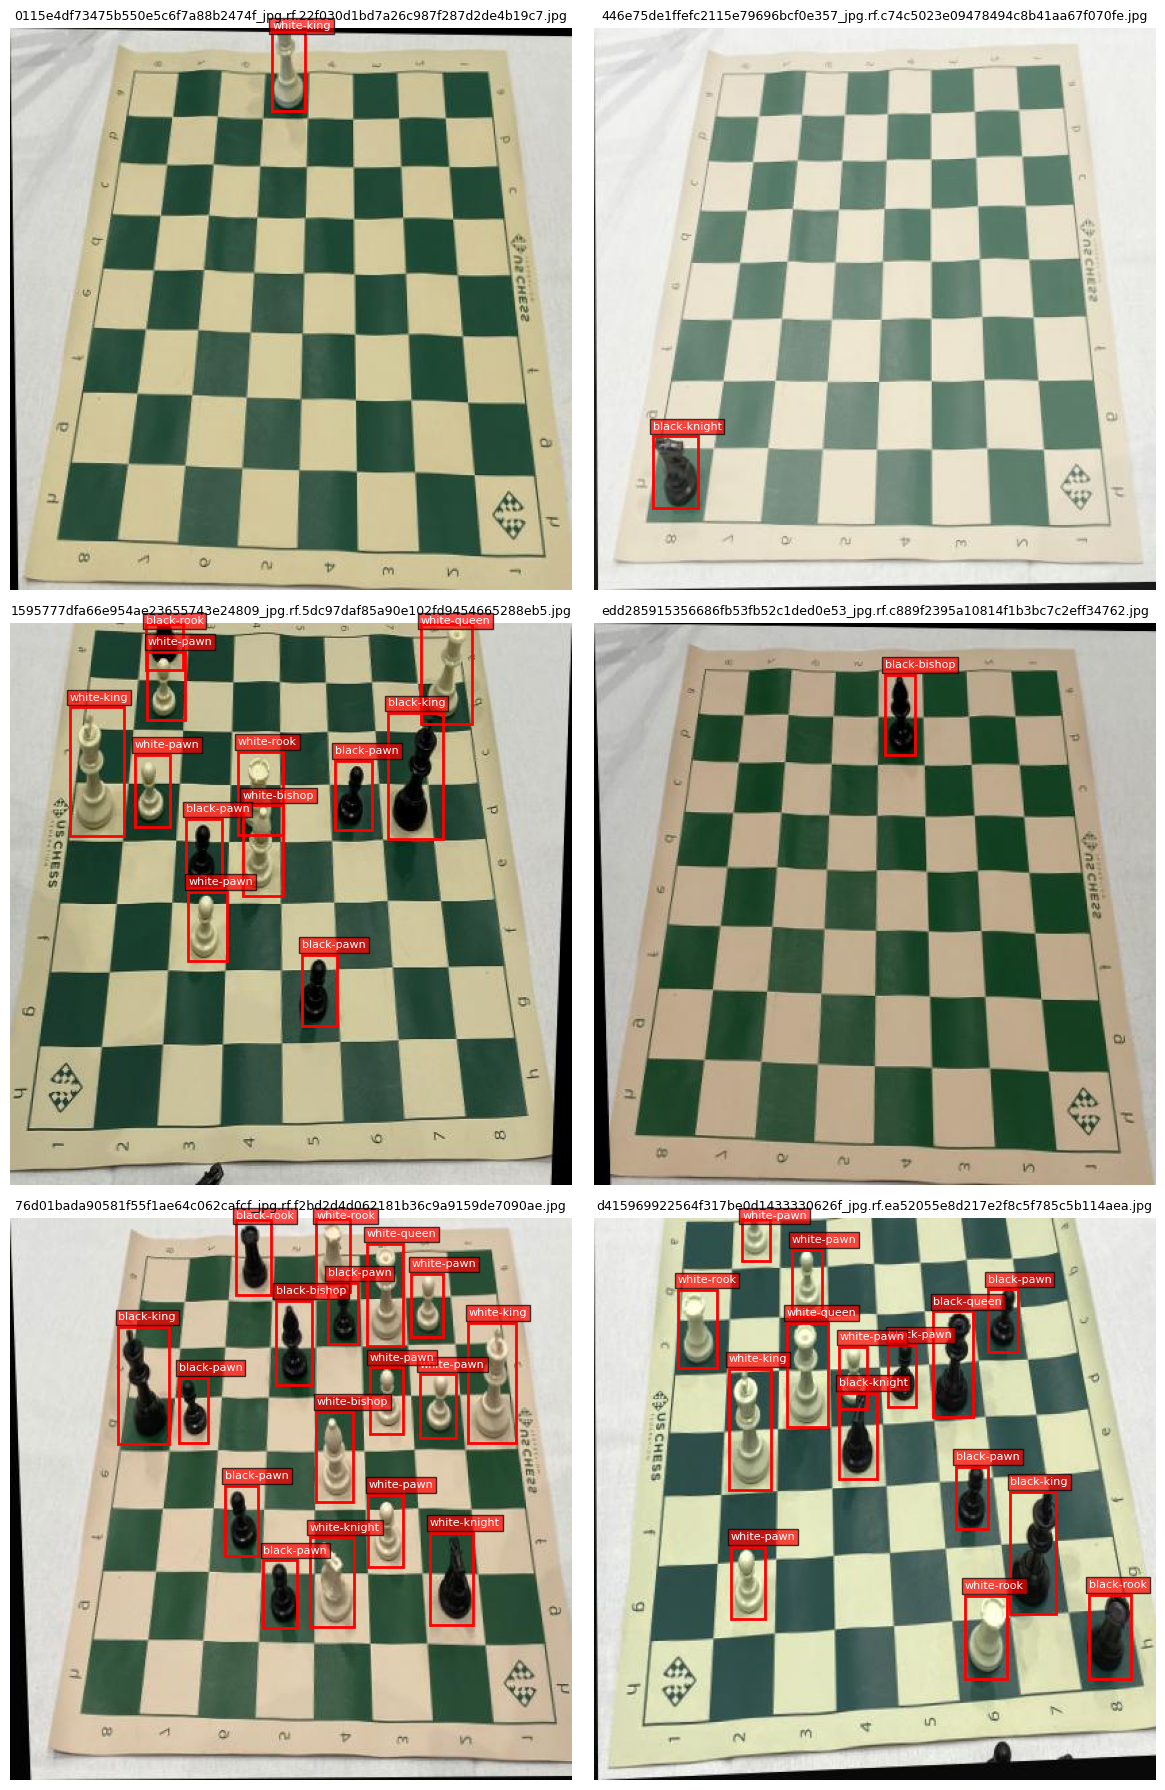

In [32]:
%matplotlib inline


import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import yaml


with open('data.yaml', 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)

images_dir = Path(data_cfg['train'])
labels_dir = images_dir.parent / 'labels'
class_names = data_cfg['names']

image_paths = sorted([p for p in images_dir.glob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}])
sample_paths = random.sample(image_paths, min(6, len(image_paths)))

fig, axes = plt.subplots(3, 2, figsize=(12, 18))
axes = axes.flatten()

for ax, image_path in zip(axes, sample_paths):
    image = Image.open(image_path).convert('RGB')
    width, height = image.size
    ax.imshow(image)

    label_path = labels_dir / f'{image_path.stem}.txt'
    if label_path.exists():
        for line in label_path.read_text(encoding='utf-8').splitlines():
            line = line.strip()
            if not line:
                continue

            class_id, x_center, y_center, box_width, box_height = line.split()
            class_id = int(class_id)
            x_center = float(x_center) * width
            y_center = float(y_center) * height
            box_width = float(box_width) * width
            box_height = float(box_height) * height

            x_min = x_center - box_width / 2
            y_min = y_center - box_height / 2

            rect = patches.Rectangle(
                (x_min, y_min),
                box_width,
                box_height,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )
            ax.add_patch(rect)

            ax.text(
                x_min,
                max(0, y_min - 5),
                class_names[class_id],
                color='white',
                fontsize=8,
                bbox=dict(facecolor='red', alpha=0.7, pad=2)
            )

    ax.set_title(image_path.name, fontsize=9)
    ax.axis('off')

for ax in axes[len(sample_paths):]:
    ax.axis('off')

plt.tight_layout()
plt.show(block=False)

### 1b) Выбрать метрики и обосновать выбор
- `mAP@0.5` выбрана как основная метрика, потому что она показывает, насколько хорошо модель находит объекты при стандартном пороге IoU.
- `mAP@0.5:0.95` выбрана как более строгая метрика, так как она оценивает качество детекции на нескольких порогах IoU и лучше отражает точность локализации объектов.

## 2. Создание бейзлайна и оценка качества

### 2a) Обучить модель из семейства YOLOv11
Baseline: `yolo11n.pt`.

### 2b) Оценить качество по выбранным метрикам

In [ ]:
baseline_model = YOLO('yolo11n.pt')
baseline_model.train(
    data='data.yaml',
    epochs=10,
    imgsz=640,
    batch=16,
    project='runs/lab1',
    name='p2_baseline',
    pretrained=True,
)

baseline_metrics = baseline_model.val(data='data.yaml', split='test')
baseline_map50 = float(baseline_metrics.box.map50)
baseline_map = float(baseline_metrics.box.map)

print('P2 baseline mAP50 =', baseline_map50)
print('P2 baseline mAP50-95 =', baseline_map)

Ultralytics 8.4.41  Python-3.13.13 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-12400F)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=p2_baseline-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

## 3. Улучшение бейзлайна

### 3a) Сформулировать гипотезы
- **1:** `imgsz=768` улучшит качество локализации.
- **2:** `epochs=10 + cos_lr=True` улучшит сходимость.
- **3:** `batch=8` на CPU даст более стабильное обучение.

### 3b) Проверить гипотезы

In [ ]:
# 1: проверка гипотезы imgsz=768
h1_model = YOLO('yolo11n.pt')
h1_model.train(
    data='data.yaml',
    epochs=10,
    imgsz=768,
    batch=16,
    project='runs/lab1',
    name='p3_h1',
    pretrained=True,
)

h1_metrics = h1_model.val(data='data.yaml', split='test')
h1_map50 = float(h1_metrics.box.map50)
h1_map = float(h1_metrics.box.map)

print('H1 mAP50 =', h1_map50)
print('H1 mAP50-95 =', h1_map)

Ultralytics 8.4.41  Python-3.13.13 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-12400F)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=p3_h1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

In [ ]:
# 2: проверка гипотезы cos_lr=True
h2_model = YOLO('yolo11n.pt')
h2_model.train(
    data='data.yaml',
    epochs=10,
    imgsz=640,
    batch=16,
    cos_lr=True,
    project='runs/lab1',
    name='p3_h2',
    pretrained=True,
)

h2_metrics = h2_model.val(data='data.yaml', split='test')
h2_map50 = float(h2_metrics.box.map50)
h2_map = float(h2_metrics.box.map)

print('H2 mAP50 =', h2_map50)
print('H2 mAP50-95 =', h2_map)

Ultralytics 8.4.41  Python-3.13.13 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-12400F)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=p3_h2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

In [ ]:
# 3: проверка гипотезы batch=8
h3_model = YOLO('yolo11n.pt')
h3_model.train(
    data='data.yaml',
    epochs=10,
    imgsz=640,
    batch=8,
    project='runs/lab1',
    name='p3_h3',
    pretrained=True,
)

h3_metrics = h3_model.val(data='data.yaml', split='test')
h3_map50 = float(h3_metrics.box.map50)
h3_map = float(h3_metrics.box.map)

print('H3 mAP50 =', h3_map50)
print('H3 mAP50-95 =', h3_map)

Ultralytics 8.4.41  Python-3.13.13 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-12400F)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=p3_h3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

### 3c) Сформировать улучшенный бейзлайн
По результатам проверок берем **гипотезу 1** (`imgsz=768`).

Коротко почему:
- у 1 гипотезы лучшие метрики из трех гипотез;
- 2 и 3 дали результаты ниже;
- 1 показала наилучшее качество среди проверенных настроек.

Итог: в качестве улучшенного бейзлайна используем результаты гипотезы 1.

### 3d) Обучить модель с улучшенным бейзлайном
Так как лучшей уже была признана гипотеза 1, её результаты принимаются как улучшенный бейзайн. Повторное обучение модели с теми же параметрами не выполнялось, так как оно заняло бы дополнительное время и не дало бы новой информации.

### 3e) Оценить качество улучшенного бейзлайна
В качестве метрик улучшенного бейщлайна используются результаты, полученные при проверке гипотезы 1.

In [ ]:
if 'h1_map50' in globals() and 'h1_map' in globals():
    improved_map50 = h1_map50
    improved_map = h1_map
else:
    from pathlib import Path
    from ultralytics import YOLO

    candidates = sorted(
        Path('.').glob('**/p3_h1/weights/best.pt'),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise FileNotFoundError

    improved_model_for_eval = YOLO(str(candidates[0]))
    improved_metrics_obj = improved_model_for_eval.val(data='data.yaml', split='test')
    improved_map50 = float(improved_metrics_obj.box.map50)
    improved_map = float(improved_metrics_obj.box.map)

print('Improved mAP@0.5      =', improved_map50)
print('Improved mAP@0.5:0.95 =', improved_map)

Ultralytics 8.4.41  Python-3.13.13 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-12400F)
val: Fast image access  (ping: 0.00.0 ms, read: 254.659.8 MB/s, size: 24.1 KB)
val: Scanning M:\Учёба\8-й сем\ИИ\test\labels.cache... 29 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 29/29 9.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.1s/it 2.2s3.9s
                   all         29        376      0.947      0.979      0.977      0.795
          black-bishop         12         21      0.933          1      0.959      0.776
            black-king         17         17       0.96      0.941      0.992      0.772
          black-knight         15         25      0.984          1      0.995      0.789
            black-pawn         16         86      0.984          1      0.986      0.813
           black-queen         14         14      0.905          1      0.981      0.805
            black-rook         16       

### 3f) Сравнить с результатами пункта 2
Сравним бейзлайн из пункта 2 с улучшенным бейзлайном, в качестве которого выбрана гипотеза 1.

In [33]:
from pathlib import Path
from ultralytics import YOLO

if 'baseline_map50' not in globals() or 'baseline_map' not in globals():
    search_roots = [Path('runs/lab1'), Path('runs/detect/runs/lab1'), Path('.')]
    candidates = []
    for root in search_roots:
        if root.exists():
            candidates.extend(root.glob('p2_baseline*/weights/best.pt'))
    if not candidates:
        candidates = list(Path('.').glob('**/p2_baseline*/weights/best.pt'))

    candidates = sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError

    baseline_model_for_compare = YOLO(str(candidates[0]))
    baseline_metrics_obj = baseline_model_for_compare.val(data='data.yaml', split='test')
    baseline_map50 = float(baseline_metrics_obj.box.map50)
    baseline_map = float(baseline_metrics_obj.box.map)

print('Сравнение baseline и improved baseline (H1):')
print('Baseline mAP@0.5      =', baseline_map50)
print('Baseline mAP@0.5:0.95 =', baseline_map)
print('Улучшенный mAP@0.5      =', improved_map50)
print('Улучшенный mAP@0.5:0.95 =', improved_map)
print('Delta mAP@0.5         =', improved_map50 - baseline_map50)
print('Delta mAP@0.5:0.95    =', improved_map - baseline_map)

Сравнение baseline и improved baseline (H1):
Baseline mAP@0.5      = 0.9776350973084185
Baseline mAP@0.5:0.95 = 0.7924202634178994
Улучшенный mAP@0.5      = 0.9785780901485377
Улучшенный mAP@0.5:0.95 = 0.7970854941240505
Delta mAP@0.5         = 0.0009429928401192278
Delta mAP@0.5:0.95    = 0.004665230706151102


### 3g) Сделать выводы

**Вывод:** по результатам пункта 3f улучшенный бейзлайн, основанный на гипотезе 1 (`imgsz=768`), показал результат чуть лучше исходного бейзлайна. Значит, для этого датасета увеличение размера изображения оказалось полезным, поэтому дальше используем именно этот вариант как улучшенный бейзлайн.

## 4. Имплементация алгоритма машинного обучения

### 4a) Самостоятельно имплементировать модель

In [13]:
from pathlib import Path

import torch
import torch.nn as nn
import yaml


with open('data.yaml', 'r', encoding='utf-8') as f:
    scratch_data_cfg = yaml.safe_load(f)

NUM_CLASSES = int(scratch_data_cfg['nc'])
CLASS_NAMES = scratch_data_cfg['names']
INPUT_SIZE = 320
GRID_SIZE = INPUT_SIZE // 32


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class ResidualBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv1 = ConvBlock(channels, channels)
        self.conv2 = ConvBlock(channels, channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.conv2(self.conv1(x))


class SimpleBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = ConvBlock(3, 16, stride=2)
        self.stage1 = nn.Sequential(
            ConvBlock(16, 32, stride=2),
            ResidualBlock(32),
        )
        self.stage2 = nn.Sequential(
            ConvBlock(32, 64, stride=2),
            ResidualBlock(64),
        )
        self.stage3 = nn.Sequential(
            ConvBlock(64, 128, stride=2),
            ResidualBlock(128),
        )
        self.stage4 = nn.Sequential(
            ConvBlock(128, 128, stride=2),
            ResidualBlock(128),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return x


class DetectionHead(nn.Module):
    def __init__(self, in_channels: int, num_classes: int):
        super().__init__()
        self.head = nn.Sequential(
            ConvBlock(in_channels, 128),
            nn.Conv2d(128, 5 + num_classes, kernel_size=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(x)


class SimpleGridDetector(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.num_classes = num_classes
        self.backbone = SimpleBackbone()
        self.neck = nn.Sequential(
            ConvBlock(128, 128),
            ConvBlock(128, 128),
        )
        self.head = DetectionHead(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x)
        x = self.neck(x)
        return self.head(x)


scratch_model = SimpleGridDetector(num_classes=NUM_CLASSES)


def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


sample_input = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE)
sample_output = scratch_model(sample_input)

print(f'Количество классов: {NUM_CLASSES}')
print(f'Имена классов: {CLASS_NAMES}')
print(f'Размер входа: {INPUT_SIZE}x{INPUT_SIZE}')
print(f'Форма выходного тензора: {tuple(sample_output.shape)}')
print(f'Число обучаемых параметров: {count_parameters(scratch_model):,}')

Количество классов: 13
Имена классов: ['bishop', 'black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook', 'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook']
Размер входа: 320x320
Форма выходного тензора: (1, 18, 10, 10)
Число обучаемых параметров: 1,374,242


### 4b) Обучить имплементированную модель

In [17]:
import copy
from pathlib import Path
from time import perf_counter

import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import yaml
from torch.utils.data import DataLoader, Dataset


if 'scratch_data_cfg' not in globals():
    with open('data.yaml', 'r', encoding='utf-8') as f:
        scratch_data_cfg = yaml.safe_load(f)

NUM_CLASSES = int(globals().get('NUM_CLASSES', scratch_data_cfg['nc']))
INPUT_SIZE = int(globals().get('INPUT_SIZE', 320))
GRID_SIZE = int(globals().get('GRID_SIZE', INPUT_SIZE // 32))

TRAIN_IMAGES_DIR = Path(scratch_data_cfg['train'])
TRAIN_LABELS_DIR = TRAIN_IMAGES_DIR.parent / 'labels'
SCRATCH_RUN_DIR = Path('runs/lab1/simple_grid_detector')
SCRATCH_RUN_DIR.mkdir(parents=True, exist_ok=True)

EPOCHS = 10
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if 'scratch_model' not in globals():
    if 'SimpleGridDetector' in globals():
        scratch_model = SimpleGridDetector(num_classes=NUM_CLASSES)
    else:
        raise RuntimeError('Сначала выполните ячейку 4a.')


class YoloDetectionDataset(Dataset):
    def __init__(self, images_dir: Path, labels_dir: Path, input_size: int, grid_size: int, num_classes: int):
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.input_size = input_size
        self.grid_size = grid_size
        self.num_classes = num_classes
        self.image_paths = sorted(
            [path for path in self.images_dir.iterdir() if path.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
        )

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, index: int):
        image_path = self.image_paths[index]
        label_path = self.labels_dir / f'{image_path.stem}.txt'

        image = Image.open(image_path).convert('RGB').resize((self.input_size, self.input_size))
        image_array = np.asarray(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image_array).permute(2, 0, 1)

        target = torch.zeros((5 + self.num_classes, self.grid_size, self.grid_size), dtype=torch.float32)

        if label_path.exists():
            for raw_line in label_path.read_text(encoding='utf-8').splitlines():
                line = raw_line.strip()
                if not line:
                    continue

                class_id, x_center, y_center, width, height = line.split()
                class_id = int(class_id)
                x_center = float(x_center)
                y_center = float(y_center)
                width = float(width)
                height = float(height)

                col = min(int(x_center * self.grid_size), self.grid_size - 1)
                row = min(int(y_center * self.grid_size), self.grid_size - 1)

                if target[4, row, col] > 0:
                    continue

                x_offset = x_center * self.grid_size - col
                y_offset = y_center * self.grid_size - row

                target[0, row, col] = x_offset
                target[1, row, col] = y_offset
                target[2, row, col] = width ** 0.5
                target[3, row, col] = height ** 0.5
                target[4, row, col] = 1.0
                target[5 + class_id, row, col] = 1.0

        return image_tensor, target


class SimpleDetectionLoss(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.num_classes = num_classes
        self.mse = nn.MSELoss(reduction='sum')
        self.bce = nn.BCEWithLogitsLoss(reduction='sum')
        self.ce = nn.CrossEntropyLoss(reduction='sum')

    def forward(self, predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        object_mask = targets[:, 4:5, :, :].bool()
        no_object_mask = ~object_mask

        xy_predictions = torch.sigmoid(predictions[:, 0:2, :, :])
        wh_predictions = torch.sigmoid(predictions[:, 2:4, :, :])

        xy_loss = self.mse(xy_predictions[object_mask.expand_as(xy_predictions)], targets[:, 0:2, :, :][object_mask.expand_as(xy_predictions)])
        wh_loss = self.mse(wh_predictions[object_mask.expand_as(wh_predictions)], targets[:, 2:4, :, :][object_mask.expand_as(wh_predictions)])

        object_logits = predictions[:, 4:5, :, :]
        if object_mask.any():
            object_loss = self.bce(object_logits[object_mask], torch.ones_like(object_logits[object_mask]))
        else:
            object_loss = predictions.sum() * 0.0

        if no_object_mask.any():
            no_object_loss = self.bce(object_logits[no_object_mask], torch.zeros_like(object_logits[no_object_mask]))
        else:
            no_object_loss = predictions.sum() * 0.0

        class_logits = predictions[:, 5:, :, :].permute(0, 2, 3, 1).reshape(-1, self.num_classes)
        class_targets = targets[:, 5:, :, :].argmax(dim=1).reshape(-1)
        active_cells = targets[:, 4:5, :, :].reshape(-1) > 0

        if active_cells.any():
            class_loss = self.ce(class_logits[active_cells], class_targets[active_cells])
        else:
            class_loss = predictions.sum() * 0.0

        total_loss = 5.0 * xy_loss + 10.0 * wh_loss + object_loss + 0.5 * no_object_loss + class_loss
        return total_loss / predictions.size(0)


train_dataset = YoloDetectionDataset(
    images_dir=TRAIN_IMAGES_DIR,
    labels_dir=TRAIN_LABELS_DIR,
    input_size=INPUT_SIZE,
    grid_size=GRID_SIZE,
    num_classes=NUM_CLASSES,
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

scratch_model = scratch_model.to(DEVICE)
criterion = SimpleDetectionLoss(num_classes=NUM_CLASSES)
optimizer = torch.optim.Adam(scratch_model.parameters(), lr=LEARNING_RATE)

best_loss = float('inf')
best_state_dict = None
scratch_history = []

print(f'device: {DEVICE}')
print(f'train_images: {len(train_dataset)}')
print(f'batch_size: {BATCH_SIZE}')
print(f'epochs: {EPOCHS}')

train_start = perf_counter()

for epoch in range(EPOCHS):
    epoch_start = perf_counter()
    scratch_model.train()
    running_loss = 0.0

    for images, targets in train_loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()
        predictions = scratch_model(images)
        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    scratch_history.append(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_state_dict = copy.deepcopy(scratch_model.state_dict())
        torch.save(best_state_dict, SCRATCH_RUN_DIR / 'best_simple_grid_detector.pt')

    epoch_time = perf_counter() - epoch_start
    print(f'epoch {epoch + 1:02d}/{EPOCHS} | loss={epoch_loss:.4f} | best={best_loss:.4f} | time={epoch_time:.1f}s')

if best_state_dict is not None:
    scratch_model.load_state_dict(best_state_dict)

total_time = perf_counter() - train_start

torch.save(scratch_model.state_dict(), SCRATCH_RUN_DIR / 'last_simple_grid_detector.pt')
print(f'best_loss={best_loss:.4f}')
print(f'total_time={total_time:.1f}s')
print(f'best_ckpt={(SCRATCH_RUN_DIR / "best_simple_grid_detector.pt").as_posix()}')
print(f'last_ckpt={(SCRATCH_RUN_DIR / "last_simple_grid_detector.pt").as_posix()}')

device: cpu
train_images: 606
batch_size: 16
epochs: 10
epoch 01/10 | loss=6.8651 | best=6.8651 | time=33.0s
epoch 02/10 | loss=3.8737 | best=3.8737 | time=34.5s
epoch 03/10 | loss=2.4379 | best=2.4379 | time=34.6s
epoch 04/10 | loss=1.5992 | best=1.5992 | time=34.3s
epoch 05/10 | loss=1.4752 | best=1.4752 | time=35.0s
epoch 06/10 | loss=1.3523 | best=1.3523 | time=34.9s
epoch 07/10 | loss=1.9467 | best=1.3523 | time=35.3s
epoch 08/10 | loss=1.1659 | best=1.1659 | time=35.2s
epoch 09/10 | loss=0.7926 | best=0.7926 | time=36.1s
epoch 10/10 | loss=0.5826 | best=0.5826 | time=35.8s
best_loss=0.5826
total_time=348.8s
best_ckpt=runs/lab1/simple_grid_detector/best_simple_grid_detector.pt
last_ckpt=runs/lab1/simple_grid_detector/last_simple_grid_detector.pt


### 4c) Оценить имплементированную модель

In [18]:
from pathlib import Path

import numpy as np
from PIL import Image
import torch
import yaml


if 'scratch_data_cfg' not in globals():
    with open('data.yaml', 'r', encoding='utf-8') as f:
        scratch_data_cfg = yaml.safe_load(f)

NUM_CLASSES = int(globals().get('NUM_CLASSES', scratch_data_cfg['nc']))
CLASS_NAMES = list(globals().get('CLASS_NAMES', scratch_data_cfg['names']))
INPUT_SIZE = int(globals().get('INPUT_SIZE', 320))
GRID_SIZE = int(globals().get('GRID_SIZE', INPUT_SIZE // 32))
DEVICE = globals().get('DEVICE', torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

if 'scratch_model' not in globals():
    if 'SimpleGridDetector' in globals():
        scratch_model = SimpleGridDetector(num_classes=NUM_CLASSES)
    else:
        raise RuntimeError('Сначала выполните ячейки 4a и 4b.')

best_ckpt_path = Path('runs/lab1/simple_grid_detector/best_simple_grid_detector.pt')
if best_ckpt_path.exists():
    scratch_model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE))

scratch_model = scratch_model.to(DEVICE)
scratch_model.eval()

TEST_IMAGES_DIR = Path(scratch_data_cfg['test'])
TEST_LABELS_DIR = TEST_IMAGES_DIR.parent / 'labels'
CONF_THRESHOLD = 0.05
NMS_THRESHOLD = 0.50
IOU_THRESHOLDS = np.arange(0.50, 1.00, 0.05)


def xywh_to_xyxy(x_center: float, y_center: float, width: float, height: float):
    x1 = max(0.0, x_center - width / 2.0)
    y1 = max(0.0, y_center - height / 2.0)
    x2 = min(1.0, x_center + width / 2.0)
    y2 = min(1.0, y_center + height / 2.0)
    return [x1, y1, x2, y2]


def box_iou(box_a, box_b) -> float:
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union_area = area_a + area_b - inter_area

    if union_area <= 0:
        return 0.0

    return inter_area / union_area


def load_image_tensor(image_path: Path) -> torch.Tensor:
    image = Image.open(image_path).convert('RGB').resize((INPUT_SIZE, INPUT_SIZE))
    image_array = np.asarray(image, dtype=np.float32) / 255.0
    image_tensor = torch.from_numpy(image_array).permute(2, 0, 1).unsqueeze(0)
    return image_tensor


def parse_ground_truth(label_path: Path):
    boxes = []

    if not label_path.exists():
        return boxes

    for raw_line in label_path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line:
            continue

        class_id, x_center, y_center, width, height = line.split()
        class_id = int(class_id)
        x_center = float(x_center)
        y_center = float(y_center)
        width = float(width)
        height = float(height)

        boxes.append(
            {
                'class_id': class_id,
                'box': xywh_to_xyxy(x_center, y_center, width, height),
            }
        )

    return boxes


def decode_predictions(prediction_map: torch.Tensor, conf_threshold: float):
    detections = []
    prediction_map = prediction_map.squeeze(0).detach().cpu()

    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            cell_prediction = prediction_map[:, row, col]
            objectness = torch.sigmoid(cell_prediction[4]).item()
            class_probs = torch.softmax(cell_prediction[5:], dim=0)
            class_score, class_id = torch.max(class_probs, dim=0)
            score = objectness * class_score.item()

            if score < conf_threshold:
                continue

            x_center = (col + torch.sigmoid(cell_prediction[0]).item()) / GRID_SIZE
            y_center = (row + torch.sigmoid(cell_prediction[1]).item()) / GRID_SIZE
            width = float(torch.sigmoid(cell_prediction[2]).item() ** 2)
            height = float(torch.sigmoid(cell_prediction[3]).item() ** 2)

            width = min(max(width, 1e-6), 1.0)
            height = min(max(height, 1e-6), 1.0)

            detections.append(
                {
                    'class_id': int(class_id.item()),
                    'score': score,
                    'box': xywh_to_xyxy(x_center, y_center, width, height),
                }
            )

    return detections


def apply_nms(detections, iou_threshold: float):
    filtered_detections = []

    for class_id in range(NUM_CLASSES):
        class_detections = [detection for detection in detections if detection['class_id'] == class_id]
        class_detections.sort(key=lambda detection: detection['score'], reverse=True)

        while class_detections:
            best_detection = class_detections.pop(0)
            filtered_detections.append(best_detection)
            class_detections = [
                detection
                for detection in class_detections
                if box_iou(best_detection['box'], detection['box']) < iou_threshold
            ]

    return filtered_detections


def compute_ap(recalls: np.ndarray, precisions: np.ndarray) -> float:
    recalls = np.concatenate(([0.0], recalls, [1.0]))
    precisions = np.concatenate(([0.0], precisions, [0.0]))

    for index in range(len(precisions) - 1, 0, -1):
        precisions[index - 1] = max(precisions[index - 1], precisions[index])

    change_points = np.where(recalls[1:] != recalls[:-1])[0]
    ap = np.sum((recalls[change_points + 1] - recalls[change_points]) * precisions[change_points + 1])
    return float(ap)


def evaluate_class(predictions_by_image, ground_truth_by_image, class_id: int, iou_threshold: float):
    predicted_boxes = []
    gt_lookup = {}
    total_gt = 0

    for image_id, ground_truths in ground_truth_by_image.items():
        class_ground_truths = [item for item in ground_truths if item['class_id'] == class_id]
        gt_lookup[image_id] = {
            'boxes': [item['box'] for item in class_ground_truths],
            'matched': [False] * len(class_ground_truths),
        }
        total_gt += len(class_ground_truths)

        for prediction in predictions_by_image[image_id]:
            if prediction['class_id'] == class_id:
                predicted_boxes.append(
                    {
                        'image_id': image_id,
                        'score': prediction['score'],
                        'box': prediction['box'],
                    }
                )

    if total_gt == 0:
        return np.nan

    if not predicted_boxes:
        return 0.0

    predicted_boxes.sort(key=lambda item: item['score'], reverse=True)

    true_positive = []
    false_positive = []

    for prediction in predicted_boxes:
        image_gt = gt_lookup[prediction['image_id']]
        best_iou = 0.0
        best_index = -1

        for index, gt_box in enumerate(image_gt['boxes']):
            if image_gt['matched'][index]:
                continue

            iou = box_iou(prediction['box'], gt_box)
            if iou > best_iou:
                best_iou = iou
                best_index = index

        if best_iou >= iou_threshold and best_index >= 0:
            image_gt['matched'][best_index] = True
            true_positive.append(1.0)
            false_positive.append(0.0)
        else:
            true_positive.append(0.0)
            false_positive.append(1.0)

    true_positive = np.cumsum(true_positive)
    false_positive = np.cumsum(false_positive)

    recalls = true_positive / max(total_gt, 1)
    precisions = true_positive / np.maximum(true_positive + false_positive, 1e-9)

    return compute_ap(recalls, precisions)


image_paths = sorted(
    [path for path in TEST_IMAGES_DIR.iterdir() if path.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
)

predictions_by_image = {}
ground_truth_by_image = {}

for image_path in image_paths:
    image_id = image_path.stem
    label_path = TEST_LABELS_DIR / f'{image_id}.txt'

    image_tensor = load_image_tensor(image_path).to(DEVICE)
    with torch.no_grad():
        prediction_map = scratch_model(image_tensor)

    predictions_by_image[image_id] = apply_nms(
        decode_predictions(prediction_map, conf_threshold=CONF_THRESHOLD),
        iou_threshold=NMS_THRESHOLD,
    )
    ground_truth_by_image[image_id] = parse_ground_truth(label_path)

class_ap50 = []
class_ap5095 = []

for class_id in range(NUM_CLASSES):
    ap_scores = [
        evaluate_class(predictions_by_image, ground_truth_by_image, class_id, iou_threshold)
        for iou_threshold in IOU_THRESHOLDS
    ]

    valid_scores = [score for score in ap_scores if not np.isnan(score)]
    if not valid_scores:
        continue

    class_ap50.append(ap_scores[0])
    class_ap5095.append(float(np.mean(valid_scores)))

scratch_map50 = float(np.mean(class_ap50)) if class_ap50 else 0.0
scratch_map = float(np.mean(class_ap5095)) if class_ap5095 else 0.0

print(f'test_images={len(image_paths)}')
print(f'evaluated_classes={len(class_ap50)}')
print(f'mAP@0.5      = {scratch_map50:.4f}')
print(f'mAP@0.5:0.95 = {scratch_map:.4f}')

test_images=29
evaluated_classes=12
mAP@0.5      = 0.8595
mAP@0.5:0.95 = 0.4505


### 4d) Сравнить с результатами п.2

In [21]:
from pathlib import Path
from ultralytics import YOLO

if 'baseline_map50' not in globals() or 'baseline_map' not in globals():
    search_roots = [Path('runs/lab1'), Path('runs/detect/runs/lab1'), Path('.')]
    candidates = []

    for root in search_roots:
        if root.exists():
            candidates.extend(root.glob('p2_baseline*/weights/best.pt'))

    if not candidates:
        candidates = list(Path('.').glob('**/p2_baseline*/weights/best.pt'))

    candidates = sorted(candidates, key=lambda path: path.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError('Не найден checkpoint baseline-модели из пункта 2.')

    baseline_model_for_compare = YOLO(str(candidates[0]))
    baseline_metrics_obj = baseline_model_for_compare.val(data='data.yaml', split='test')
    baseline_map50 = float(baseline_metrics_obj.box.map50)
    baseline_map = float(baseline_metrics_obj.box.map)

delta_map50 = scratch_map50 - baseline_map50
delta_map = scratch_map - baseline_map

print('Сравнение имплементированной модели с бейзлайном из п.2:')
print(f'Имлементированный mAP@0.5      = {scratch_map50:.4f}')
print(f'Имлементированный mAP@0.5:0.95 = {scratch_map:.4f}')
print(f'Baseline mAP@0.5               = {baseline_map50:.4f}')
print(f'Baseline mAP@0.5:0.95          = {baseline_map:.4f}')
print(f'Delta mAP@0.5                  = {delta_map50:.4f}')
print(f'Delta mAP@0.5:0.95             = {delta_map:.4f}')

Ultralytics 8.4.41  Python-3.13.13 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-12400F)
YOLO11n summary (fused): 101 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 495.8169.7 MB/s, size: 24.5 KB)
val: Scanning M:\Учёба\8-й сем\ИИ\test\labels.cache... 29 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 29/29 4.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0s/it 2.0s3.7s
                   all         29        376      0.934      0.956      0.978      0.792
          black-bishop         12         21      0.947          1      0.989      0.801
            black-king         17         17          1      0.991      0.995      0.826
          black-knight         15         25      0.988          1      0.995      0.813
            black-pawn         16         86      0.985          1      0.994      0.796
           black-queen         14         14 

### 4e) Сделать выводы
Имплементированная модель показала результат ниже, чем baseline-модель из пункта 2: `mAP@0.5 = 0.8595` против `0.9776`, а `mAP@0.5:0.95 = 0.4505` против `0.7924`.

Это означает, что упрощенная собственная архитектура уже способна достаточно хорошо находить объекты на изображении, но по точности локализации и общему качеству все еще уступает предобученной модели `YOLO11n`. Следовательно, использование готовых предобученных весов и более сильной архитектуры дает заметное преимущество в задаче детекции объектов.

### 4f) Добавить техники из улучшенного бейзлайна (п.3c)
В качестве техники из улучшенного бейзлайна используется идея увеличения входного разрешения изображения. Для собственной модели эта техника переносится через увеличение `INPUT_SIZE` при обучении и оценке модели.

### 4g) Обучить модель с добавленными техниками

In [22]:
import copy
from pathlib import Path
from time import perf_counter

import torch


if 'SimpleGridDetector' not in globals() or 'YoloDetectionDataset' not in globals() or 'SimpleDetectionLoss' not in globals():
    raise RuntimeError('Сначала выполните ячейки 4a и 4b.')

IMPROVED_INPUT_SIZE = 416
IMPROVED_GRID_SIZE = IMPROVED_INPUT_SIZE // 32
IMPROVED_EPOCHS = 10
IMPROVED_BATCH_SIZE = 8
IMPROVED_LEARNING_RATE = 1e-3

TRAIN_IMAGES_DIR = Path(scratch_data_cfg['train'])
TRAIN_LABELS_DIR = TRAIN_IMAGES_DIR.parent / 'labels'
IMPROVED_RUN_DIR = Path('runs/lab1/simple_grid_detector_improved')
IMPROVED_RUN_DIR.mkdir(parents=True, exist_ok=True)

scratch_improved_model = SimpleGridDetector(num_classes=NUM_CLASSES).to(DEVICE)
improved_criterion = SimpleDetectionLoss(num_classes=NUM_CLASSES)
improved_optimizer = torch.optim.Adam(scratch_improved_model.parameters(), lr=IMPROVED_LEARNING_RATE)

improved_train_dataset = YoloDetectionDataset(
    images_dir=TRAIN_IMAGES_DIR,
    labels_dir=TRAIN_LABELS_DIR,
    input_size=IMPROVED_INPUT_SIZE,
    grid_size=IMPROVED_GRID_SIZE,
    num_classes=NUM_CLASSES,
)
improved_train_loader = DataLoader(improved_train_dataset, batch_size=IMPROVED_BATCH_SIZE, shuffle=True, num_workers=0)

best_improved_loss = float('inf')
best_improved_state_dict = None
scratch_improved_history = []

print(f'device: {DEVICE}')
print(f'train_images: {len(improved_train_dataset)}')
print(f'input_size: {IMPROVED_INPUT_SIZE}')
print(f'grid_size: {IMPROVED_GRID_SIZE}')
print(f'batch_size: {IMPROVED_BATCH_SIZE}')
print(f'epochs: {IMPROVED_EPOCHS}')

improved_train_start = perf_counter()

for epoch in range(IMPROVED_EPOCHS):
    epoch_start = perf_counter()
    scratch_improved_model.train()
    running_loss = 0.0

    for images, targets in improved_train_loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        improved_optimizer.zero_grad()
        predictions = scratch_improved_model(images)
        loss = improved_criterion(predictions, targets)
        loss.backward()
        improved_optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(improved_train_loader)
    scratch_improved_history.append(epoch_loss)

    if epoch_loss < best_improved_loss:
        best_improved_loss = epoch_loss
        best_improved_state_dict = copy.deepcopy(scratch_improved_model.state_dict())
        torch.save(best_improved_state_dict, IMPROVED_RUN_DIR / 'best_simple_grid_detector_improved.pt')

    epoch_time = perf_counter() - epoch_start
    print(f'epoch {epoch + 1:02d}/{IMPROVED_EPOCHS} | loss={epoch_loss:.4f} | best={best_improved_loss:.4f} | time={epoch_time:.1f}s')

if best_improved_state_dict is not None:
    scratch_improved_model.load_state_dict(best_improved_state_dict)

improved_total_time = perf_counter() - improved_train_start

torch.save(scratch_improved_model.state_dict(), IMPROVED_RUN_DIR / 'last_simple_grid_detector_improved.pt')
print(f'best_loss={best_improved_loss:.4f}')
print(f'total_time={improved_total_time:.1f}s')
print(f'best_ckpt={(IMPROVED_RUN_DIR / "best_simple_grid_detector_improved.pt").as_posix()}')
print(f'last_ckpt={(IMPROVED_RUN_DIR / "last_simple_grid_detector_improved.pt").as_posix()}')

device: cpu
train_images: 606
input_size: 416
grid_size: 13
batch_size: 8
epochs: 10
epoch 01/10 | loss=48.9896 | best=48.9896 | time=20.5s
epoch 02/10 | loss=17.2912 | best=17.2912 | time=19.8s
epoch 03/10 | loss=10.1392 | best=10.1392 | time=20.6s
epoch 04/10 | loss=7.3158 | best=7.3158 | time=20.9s
epoch 05/10 | loss=4.8577 | best=4.8577 | time=21.4s
epoch 06/10 | loss=3.3334 | best=3.3334 | time=21.4s
epoch 07/10 | loss=2.8460 | best=2.8460 | time=21.8s
epoch 08/10 | loss=1.9230 | best=1.9230 | time=21.9s
epoch 09/10 | loss=1.3295 | best=1.3295 | time=21.7s
epoch 10/10 | loss=0.9869 | best=0.9869 | time=21.9s
best_loss=0.9869
total_time=211.9s
best_ckpt=runs/lab1/simple_grid_detector_improved/best_simple_grid_detector_improved.pt
last_ckpt=runs/lab1/simple_grid_detector_improved/last_simple_grid_detector_improved.pt


### 4h) Оценить её

In [23]:
from pathlib import Path

import numpy as np
from PIL import Image
import torch
import yaml


if 'scratch_data_cfg' not in globals():
    with open('data.yaml', 'r', encoding='utf-8') as f:
        scratch_data_cfg = yaml.safe_load(f)

NUM_CLASSES = int(globals().get('NUM_CLASSES', scratch_data_cfg['nc']))
IMPROVED_INPUT_SIZE = int(globals().get('IMPROVED_INPUT_SIZE', 416))
IMPROVED_GRID_SIZE = int(globals().get('IMPROVED_GRID_SIZE', IMPROVED_INPUT_SIZE // 32))
DEVICE = globals().get('DEVICE', torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

if 'scratch_improved_model' not in globals():
    if 'SimpleGridDetector' in globals():
        scratch_improved_model = SimpleGridDetector(num_classes=NUM_CLASSES)
    else:
        raise RuntimeError('Сначала выполните ячейки 4a и 4g.')

improved_ckpt_path = Path('runs/lab1/simple_grid_detector_improved/best_simple_grid_detector_improved.pt')
if improved_ckpt_path.exists():
    scratch_improved_model.load_state_dict(torch.load(improved_ckpt_path, map_location=DEVICE))

scratch_improved_model = scratch_improved_model.to(DEVICE)
scratch_improved_model.eval()

TEST_IMAGES_DIR = Path(scratch_data_cfg['test'])
TEST_LABELS_DIR = TEST_IMAGES_DIR.parent / 'labels'
IMPROVED_CONF_THRESHOLD = 0.05
IMPROVED_NMS_THRESHOLD = 0.50
IMPROVED_IOU_THRESHOLDS = np.arange(0.50, 1.00, 0.05)


def improved_xywh_to_xyxy(x_center: float, y_center: float, width: float, height: float):
    x1 = max(0.0, x_center - width / 2.0)
    y1 = max(0.0, y_center - height / 2.0)
    x2 = min(1.0, x_center + width / 2.0)
    y2 = min(1.0, y_center + height / 2.0)
    return [x1, y1, x2, y2]


def improved_box_iou(box_a, box_b) -> float:
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union_area = area_a + area_b - inter_area

    if union_area <= 0:
        return 0.0

    return inter_area / union_area


def improved_load_image_tensor(image_path: Path) -> torch.Tensor:
    image = Image.open(image_path).convert('RGB').resize((IMPROVED_INPUT_SIZE, IMPROVED_INPUT_SIZE))
    image_array = np.asarray(image, dtype=np.float32) / 255.0
    image_tensor = torch.from_numpy(image_array).permute(2, 0, 1).unsqueeze(0)
    return image_tensor


def improved_parse_ground_truth(label_path: Path):
    boxes = []

    if not label_path.exists():
        return boxes

    for raw_line in label_path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line:
            continue

        class_id, x_center, y_center, width, height = line.split()
        boxes.append(
            {
                'class_id': int(class_id),
                'box': improved_xywh_to_xyxy(float(x_center), float(y_center), float(width), float(height)),
            }
        )

    return boxes


def improved_decode_predictions(prediction_map: torch.Tensor, conf_threshold: float):
    detections = []
    prediction_map = prediction_map.squeeze(0).detach().cpu()

    for row in range(IMPROVED_GRID_SIZE):
        for col in range(IMPROVED_GRID_SIZE):
            cell_prediction = prediction_map[:, row, col]
            objectness = torch.sigmoid(cell_prediction[4]).item()
            class_probs = torch.softmax(cell_prediction[5:], dim=0)
            class_score, class_id = torch.max(class_probs, dim=0)
            score = objectness * class_score.item()

            if score < conf_threshold:
                continue

            x_center = (col + torch.sigmoid(cell_prediction[0]).item()) / IMPROVED_GRID_SIZE
            y_center = (row + torch.sigmoid(cell_prediction[1]).item()) / IMPROVED_GRID_SIZE
            width = float(torch.sigmoid(cell_prediction[2]).item() ** 2)
            height = float(torch.sigmoid(cell_prediction[3]).item() ** 2)

            width = min(max(width, 1e-6), 1.0)
            height = min(max(height, 1e-6), 1.0)

            detections.append(
                {
                    'class_id': int(class_id.item()),
                    'score': score,
                    'box': improved_xywh_to_xyxy(x_center, y_center, width, height),
                }
            )

    return detections


def improved_apply_nms(detections, iou_threshold: float):
    filtered_detections = []

    for class_id in range(NUM_CLASSES):
        class_detections = [detection for detection in detections if detection['class_id'] == class_id]
        class_detections.sort(key=lambda detection: detection['score'], reverse=True)

        while class_detections:
            best_detection = class_detections.pop(0)
            filtered_detections.append(best_detection)
            class_detections = [
                detection
                for detection in class_detections
                if improved_box_iou(best_detection['box'], detection['box']) < iou_threshold
            ]

    return filtered_detections


def improved_compute_ap(recalls: np.ndarray, precisions: np.ndarray) -> float:
    recalls = np.concatenate(([0.0], recalls, [1.0]))
    precisions = np.concatenate(([0.0], precisions, [0.0]))

    for index in range(len(precisions) - 1, 0, -1):
        precisions[index - 1] = max(precisions[index - 1], precisions[index])

    change_points = np.where(recalls[1:] != recalls[:-1])[0]
    ap = np.sum((recalls[change_points + 1] - recalls[change_points]) * precisions[change_points + 1])
    return float(ap)


def improved_evaluate_class(predictions_by_image, ground_truth_by_image, class_id: int, iou_threshold: float):
    predicted_boxes = []
    gt_lookup = {}
    total_gt = 0

    for image_id, ground_truths in ground_truth_by_image.items():
        class_ground_truths = [item for item in ground_truths if item['class_id'] == class_id]
        gt_lookup[image_id] = {
            'boxes': [item['box'] for item in class_ground_truths],
            'matched': [False] * len(class_ground_truths),
        }
        total_gt += len(class_ground_truths)

        for prediction in predictions_by_image[image_id]:
            if prediction['class_id'] == class_id:
                predicted_boxes.append(
                    {
                        'image_id': image_id,
                        'score': prediction['score'],
                        'box': prediction['box'],
                    }
                )

    if total_gt == 0:
        return np.nan

    if not predicted_boxes:
        return 0.0

    predicted_boxes.sort(key=lambda item: item['score'], reverse=True)

    true_positive = []
    false_positive = []

    for prediction in predicted_boxes:
        image_gt = gt_lookup[prediction['image_id']]
        best_iou = 0.0
        best_index = -1

        for index, gt_box in enumerate(image_gt['boxes']):
            if image_gt['matched'][index]:
                continue

            iou = improved_box_iou(prediction['box'], gt_box)
            if iou > best_iou:
                best_iou = iou
                best_index = index

        if best_iou >= iou_threshold and best_index >= 0:
            image_gt['matched'][best_index] = True
            true_positive.append(1.0)
            false_positive.append(0.0)
        else:
            true_positive.append(0.0)
            false_positive.append(1.0)

    true_positive = np.cumsum(true_positive)
    false_positive = np.cumsum(false_positive)

    recalls = true_positive / max(total_gt, 1)
    precisions = true_positive / np.maximum(true_positive + false_positive, 1e-9)

    return improved_compute_ap(recalls, precisions)


image_paths = sorted(
    [path for path in TEST_IMAGES_DIR.iterdir() if path.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
)

improved_predictions_by_image = {}
improved_ground_truth_by_image = {}

for image_path in image_paths:
    image_id = image_path.stem
    label_path = TEST_LABELS_DIR / f'{image_id}.txt'

    image_tensor = improved_load_image_tensor(image_path).to(DEVICE)
    with torch.no_grad():
        prediction_map = scratch_improved_model(image_tensor)

    improved_predictions_by_image[image_id] = improved_apply_nms(
        improved_decode_predictions(prediction_map, conf_threshold=IMPROVED_CONF_THRESHOLD),
        iou_threshold=IMPROVED_NMS_THRESHOLD,
    )
    improved_ground_truth_by_image[image_id] = improved_parse_ground_truth(label_path)

improved_class_ap50 = []
improved_class_ap5095 = []

for class_id in range(NUM_CLASSES):
    ap_scores = [
        improved_evaluate_class(improved_predictions_by_image, improved_ground_truth_by_image, class_id, iou_threshold)
        for iou_threshold in IMPROVED_IOU_THRESHOLDS
    ]

    valid_scores = [score for score in ap_scores if not np.isnan(score)]
    if not valid_scores:
        continue

    improved_class_ap50.append(ap_scores[0])
    improved_class_ap5095.append(float(np.mean(valid_scores)))

scratch_improved_map50 = float(np.mean(improved_class_ap50)) if improved_class_ap50 else 0.0
scratch_improved_map = float(np.mean(improved_class_ap5095)) if improved_class_ap5095 else 0.0

print(f'test_images={len(image_paths)}')
print(f'evaluated_classes={len(improved_class_ap50)}')
print(f'Имплементированный с улучшенным бейзлайном mAP@0.5      = {scratch_improved_map50:.4f}')
print(f'Имплементированный с улучшенным бейзлайном mAP@0.5:0.95 = {scratch_improved_map:.4f}')

test_images=29
evaluated_classes=12
Имплементированный с улучшенным бейзлайном mAP@0.5      = 0.8577
Имплементированный с улучшенным бейзлайном mAP@0.5:0.95 = 0.4240


### 4i) Сравнить с результатами п.3

In [24]:
from pathlib import Path
from ultralytics import YOLO

if 'improved_map50' not in globals() or 'improved_map' not in globals():
    search_roots = [Path('runs/lab1'), Path('runs/detect/runs/lab1'), Path('.')]
    candidates = []

    for root in search_roots:
        if root.exists():
            candidates.extend(root.glob('p3_h1*/weights/best.pt'))

    if not candidates:
        candidates = list(Path('.').glob('**/p3_h1*/weights/best.pt'))

    candidates = sorted(candidates, key=lambda path: path.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError('Не найден checkpoint improved baseline из пункта 3.')

    improved_model_for_compare = YOLO(str(candidates[0]))
    improved_metrics_obj = improved_model_for_compare.val(data='data.yaml', split='test')
    improved_map50 = float(improved_metrics_obj.box.map50)
    improved_map = float(improved_metrics_obj.box.map)

delta_improved_map50 = scratch_improved_map50 - improved_map50
delta_improved_map = scratch_improved_map - improved_map

print('Сравнение имплементированной модели с улучшенным бейзлайном из п.3:')
print(f'Имплементированный mAP@0.5      = {scratch_improved_map50:.4f}')
print(f'Имплементированный mAP@0.5:0.95 = {scratch_improved_map:.4f}')
print(f'Improved baseline mAP@0.5       = {improved_map50:.4f}')
print(f'Improved baseline mAP@0.5:0.95  = {improved_map:.4f}')
print(f'Delta mAP@0.5                   = {delta_improved_map50:.4f}')
print(f'Delta mAP@0.5:0.95              = {delta_improved_map:.4f}')

Ultralytics 8.4.41  Python-3.13.13 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-12400F)
YOLO11n summary (fused): 101 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 365.869.9 MB/s, size: 22.9 KB)
val: Scanning M:\Учёба\8-й сем\ИИ\test\labels.cache... 29 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 29/29 10.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4s/it 2.7s4.9s
                   all         29        376      0.963      0.976      0.979      0.797
          black-bishop         12         21      0.941          1      0.989      0.822
            black-king         17         17      0.984          1      0.995      0.847
          black-knight         15         25      0.996          1      0.995      0.786
            black-pawn         16         86      0.986          1      0.992      0.804
           black-queen         14         14 

### 4j) Сделать выводы
После переноса техники из улучшенного бейзлайна на собственную модель качество осталось сопоставимым с результатом из пункта 4c, но заметного прироста не произошло: `mAP@0.5 = 0.8577` против `0.8595`, а `mAP@0.5:0.95 = 0.4240` против `0.4505`.

Это означает, что увеличение входного разрешения само по себе не дало улучшения для упрощенной собственной архитектуры. Следовательно, такая техника оказалась полезной для baseline-модели из пункта 3, но для имплементированной модели решающего выигрыша не принесла.